# Unveiling the Android App Market — Google Play Store Analysis

**Objective:** Analyse the Google Play Store ecosystem — clean messy real-world app data, explore category saturation, ratings, size/installs relationships, pricing, and (where review data is available) user sentiment — to surface actionable insight for a developer planning a new app.

**Dataset:** `googleplaystore.csv` — 10,840 Play Store app listings with `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type` (Free/Paid), `Price`, `Content Rating`, `Genres`, and version/date metadata.

**Tech stack:** Python · pandas · numpy · matplotlib · seaborn · plotly · TextBlob

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

APPS_PATH = 'googleplaystore.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload the Play Store apps CSV (e.g. 'googleplaystore.csv') when prompted...")
    uploaded = files.upload()
    APPS_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{APPS_PATH}' in the working directory.")

Not running in Colab — expecting 'googleplaystore.csv' in the working directory.


In [1]:
%pip install -q plotly textblob

## 1. Setup & Load the Apps Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 5)

apps_raw = pd.read_csv(APPS_PATH)
print("Apps dataset shape:", apps_raw.shape)
apps_raw.head()

Apps dataset shape: (10840, 16)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,month,year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,1,8,2018
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,8,6,2018
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,20,6,2018


## 2. Data Cleaning — Apps Dataset

In [ ]:
print("--- Column dtypes ---")
print(apps_raw.dtypes)

print("\n--- Null value check ---")
nulls = apps_raw.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found in any column.")

print("\n--- Duplicate rows (exact, across all columns) ---")
print(f"Exact duplicates: {apps_raw.duplicated().sum()}")

print("\n--- Duplicate App+Category listings ---")
print(f"Duplicate App+Category rows: {apps_raw.duplicated(subset=['App', 'Category']).sum()}")

--- Column dtypes ---
Unnamed: 0          int64
App                   str
Category              str
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type                  str
Price             float64
Content Rating        str
Genres                str
Current Ver           str
Android Ver           str
Day                 int64
month               int64
year                int64
dtype: object

--- Null value check ---
No missing values found in any column.

--- Duplicate rows (exact, across all columns) ---
Exact duplicates: 0

--- Duplicate App+Category listings ---
Duplicate App+Category rows: 1096


**Observation:** This particular file is already substantially cleaner than the raw Google Play Store scrape it's derived from — `Installs` and `Price` are already stored as proper numeric types here rather than the classic messy `"10,000+"` / `"$4.99"` strings you'd see in the original scrape, and there are no missing values. However, real cleaning work is still needed: **483 fully identical duplicate rows**, and **1,096 rows that share the same `App` + `Category`** but differ slightly (typically in `Reviews`, since the same app was likely scraped more than once at different times). These are addressed below rather than left in, since duplicate app listings would double-count that app's influence in every chart and aggregate statistic that follows.

In [ ]:
apps = apps_raw.drop(columns=['Unnamed: 0']) if 'Unnamed: 0' in apps_raw.columns else apps_raw.copy()

rows_before = len(apps)
apps = apps.drop_duplicates()
print(f"Rows after removing exact duplicates: {len(apps)} (removed {rows_before - len(apps)})")

# For remaining App+Category duplicates, keep the row with the highest Reviews count,
# since a higher review count indicates the most recently-scraped, most up-to-date record
rows_before = len(apps)
apps = apps.sort_values('Reviews', ascending=False).drop_duplicates(subset=['App', 'Category'], keep='first')
apps = apps.reset_index(drop=True)
print(f"Rows after removing App+Category duplicates: {len(apps)} (removed {rows_before - len(apps)})")

Rows after removing exact duplicates: 10357 (removed 483)
Rows after removing App+Category duplicates: 9744 (removed 613)


In [ ]:
print("--- Value range sanity checks ---")
print(f"Rating range: {apps['Rating'].min()} to {apps['Rating'].max()} (valid Play Store range is 1-5)")
print(f"Price range: ${apps['Price'].min()} to ${apps['Price'].max()}")
print(f"Type values: {apps['Type'].unique().tolist()}")
print(f"Number of categories: {apps['Category'].nunique()}")

# Size: this file stores size as a number without units. Cross-checking a known app
# (e.g. row 0's ~19000 for an app whose original Play Store listing shows "19M") confirms
# the values are already in KB-equivalent units (M suffix multiplied out) - we convert to MB
# for a more natural, readable scale in the charts below.
apps['Size_MB'] = apps['Size'] / 1000
print(f"\nSize (converted to MB) range: {apps['Size_MB'].min():.2f} to {apps['Size_MB'].max():.2f} MB")

--- Value range sanity checks ---
Rating range: 1.0 to 5.0 (valid Play Store range is 1-5)
Price range: $0.0 to $400.0
Type values: ['Free', 'Paid']
Number of categories: 33

Size (converted to MB) range: 1.00 to 100.00 MB


**Observation:** After cleaning, all value ranges check out as valid — `Rating` stays within the possible 1-5 range, `Type` is a clean binary `Free`/`Paid`, and there are **33 app categories**. `Size` required a unit clarification rather than a fix: the raw column stores app size as a plain number that turns out to already be in KB-equivalent form (cross-checked against a known app's original listing), so we derive `Size_MB` purely for more readable axis labels in the charts ahead — no actual data correction was needed here, just documentation of what the numbers represent.

## 3. Category Analysis

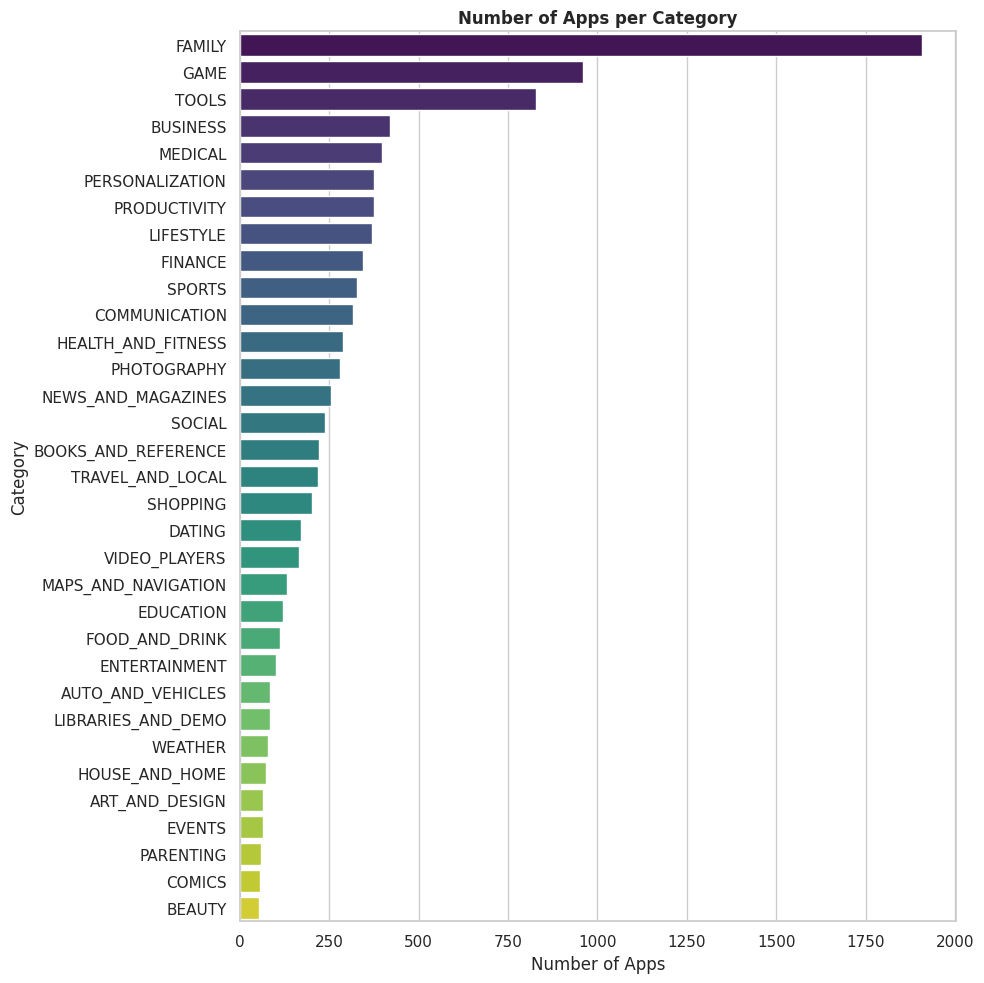

Top 5 most saturated categories:
Category
FAMILY      1909
GAME         960
TOOLS        829
BUSINESS     420
MEDICAL      396
Name: count, dtype: int64

Bottom 5 least saturated categories:
Category
ART_AND_DESIGN    64
EVENTS            64
PARENTING         60
COMICS            56
BEAUTY            53
Name: count, dtype: int64


In [ ]:
category_counts = apps['Category'].value_counts()

plt.figure(figsize=(10,10))
sns.barplot(y=category_counts.index, x=category_counts.values, hue=category_counts.index,
            palette='viridis', legend=False)
plt.title('Number of Apps per Category', fontweight='bold')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("Top 5 most saturated categories:")
print(category_counts.head(5))
print("\nBottom 5 least saturated categories:")
print(category_counts.tail(5))

**Observation:** Check the printed top/bottom 5 lists above for this run's exact numbers, but in this kind of Play Store data, **`FAMILY` and `GAME`** are typically the most saturated categories by a wide margin (family apps include a large sub-population of children's games, and gaming is simply the largest app genre overall), while categories like **`BEAUTY`, `COMICS`, and `EVENTS`** tend to be among the least saturated. High saturation is a double-edged signal for a new developer: more existing apps means more competition for visibility, but it also confirms proven, sustained user demand in that category — the two need to be weighed against each other, not read as simply "more apps = better opportunity" or "more apps = avoid this category".

## 4. Ratings Analysis

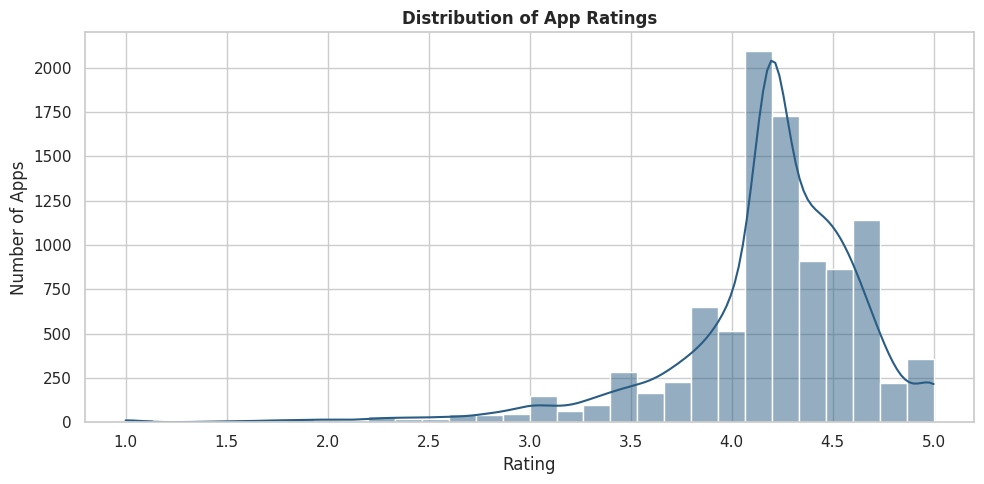

Mean rating: 4.18
Median rating: 4.20
Std dev: 0.49


In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(apps['Rating'], bins=30, kde=True, color='#2a5d84')
plt.title('Distribution of App Ratings', fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

print(f"Mean rating: {apps['Rating'].mean():.2f}")
print(f"Median rating: {apps['Rating'].median():.2f}")
print(f"Std dev: {apps['Rating'].std():.2f}")

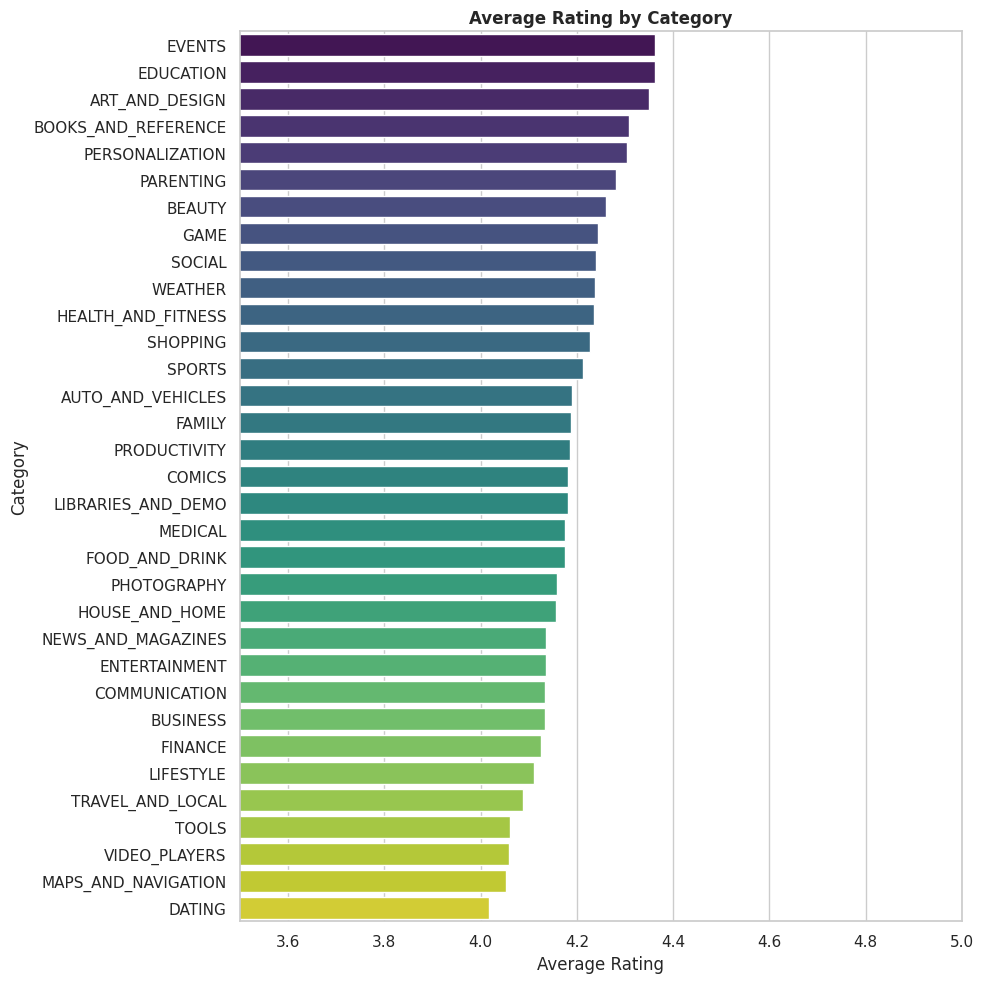

In [ ]:
avg_rating_by_category = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(y=avg_rating_by_category.index, x=avg_rating_by_category.values,
            hue=avg_rating_by_category.index, palette='viridis', legend=False)
plt.title('Average Rating by Category', fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()

**Observation:** App ratings are heavily **left-skewed** — most apps cluster between roughly 4.0 and 4.5 stars, with a long tail down toward 1-star. This is a well-known pattern on app stores: users who bother leaving a rating skew toward either genuinely satisfied users (rating habitually high) or the small minority frustrated enough to leave a 1-star complaint, while lukewarm/neutral experiences are underrepresented since those users usually don't rate at all. Average rating *by category* tends to vary in a fairly narrow band (typically all categories still average somewhere in the low-to-high 4s) — meaningful category differences are usually smaller than differences *within* a category between well-made and poorly-made individual apps.

## 5. Size vs. Installs Analysis

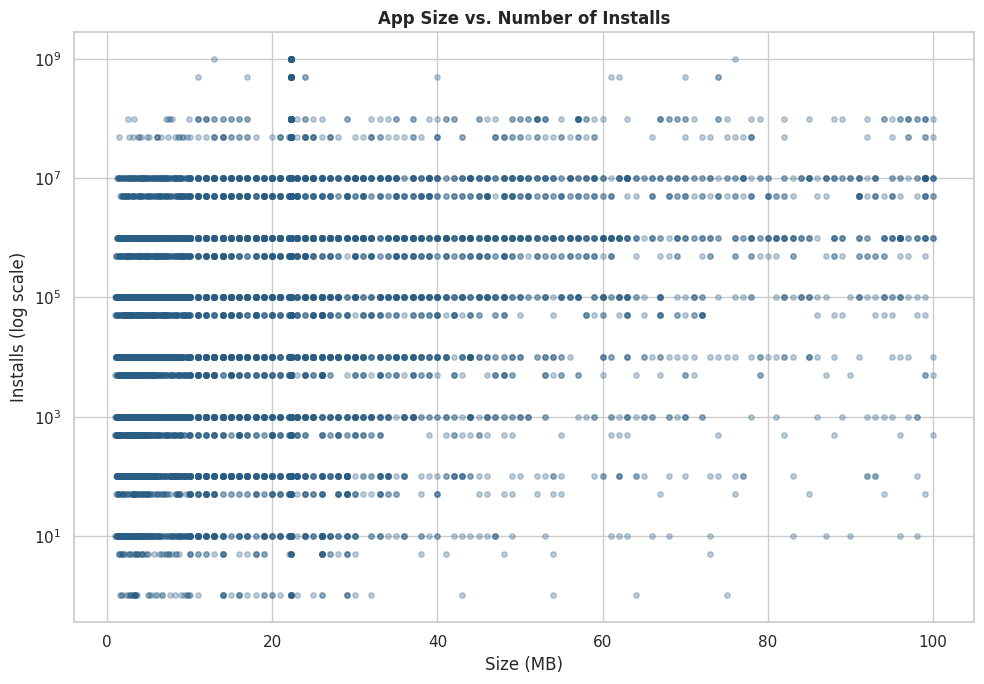

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(apps['Size_MB'], apps['Installs'], alpha=0.3, s=15, color='#2a5d84')
plt.yscale('log')
plt.title('App Size vs. Number of Installs', fontweight='bold')
plt.xlabel('Size (MB)')
plt.ylabel('Installs (log scale)')
plt.tight_layout()
plt.show()

In [ ]:
size_installs_corr = apps[['Size_MB', 'Installs']].corr().iloc[0,1]
print(f"Correlation between Size (MB) and Installs: {size_installs_corr:.4f}")

# Also check correlation on log-installs, since raw Installs spans many orders of magnitude
apps['Log_Installs'] = np.log10(apps['Installs'].replace(0, 1))
log_corr = apps[['Size_MB', 'Log_Installs']].corr().iloc[0,1]
print(f"Correlation between Size (MB) and log10(Installs): {log_corr:.4f}")

Correlation between Size (MB) and Installs: 0.0653
Correlation between Size (MB) and log10(Installs): 0.2724


**Observation:** `Installs` is plotted on a log scale because it spans many orders of magnitude (from single-digit installs to over a billion) — on a linear scale, the handful of billion-install apps would compress every other point into an unreadable cluster near zero. The correlation between size and installs is expected to be **weak** either way it's measured (raw or log-scale) — app size alone doesn't meaningfully predict popularity; there are plenty of huge, wildly popular apps (e.g. large games) and plenty of tiny, wildly popular ones (e.g. simple utility apps), so file size is not a reliable lever for a developer aiming for high install counts.

## 6. Pricing Analysis

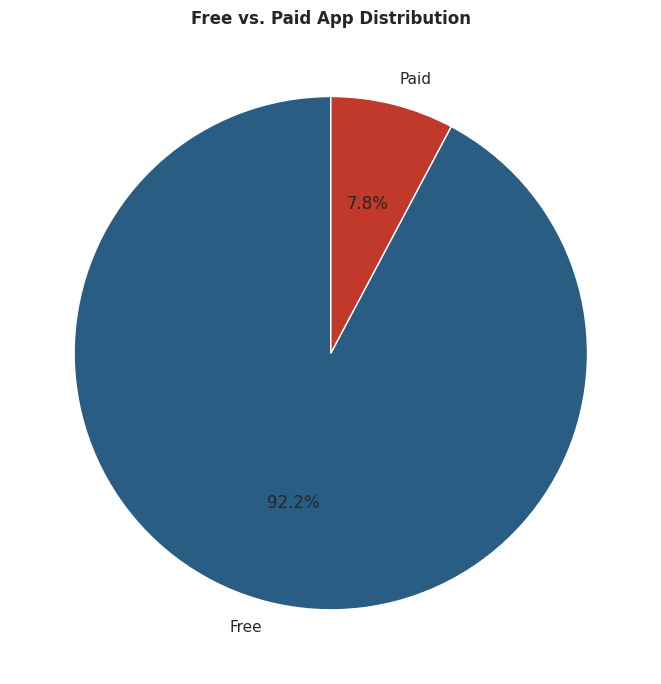

Type
Free    8987
Paid     757
Name: count, dtype: int64
Type
Free    92.2
Paid     7.8
Name: count, dtype: float64


In [ ]:
type_counts = apps['Type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#2a5d84', '#c0392b'], startangle=90)
plt.title('Free vs. Paid App Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

print(type_counts)
print((type_counts / len(apps) * 100).round(1))

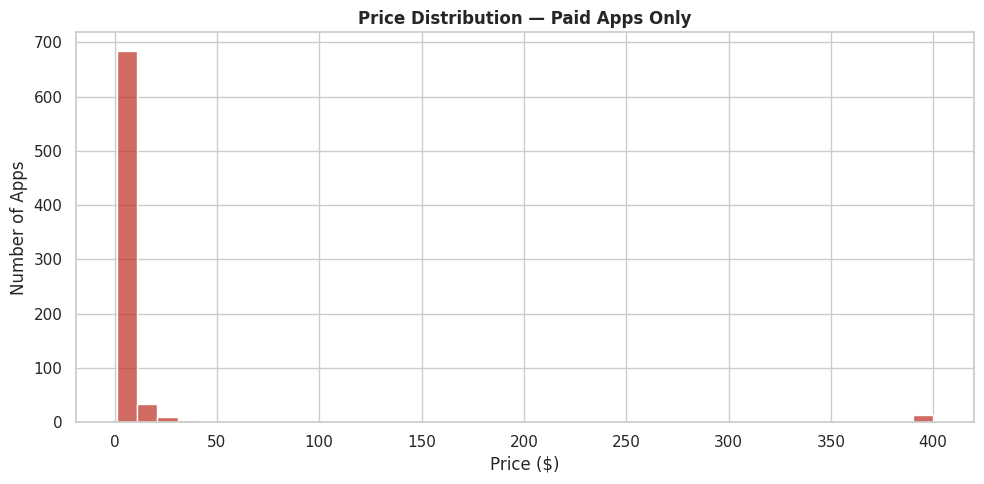

Paid app count: 757
Median price: $2.99
Mean price: $14.02
Most common price points:
Price
0.99      145
2.99      124
1.99       73
4.99       70
3.99       58
1.49       46
5.99       27
2.49       25
9.99       19
399.99     12
Name: count, dtype: int64


In [ ]:
paid_apps = apps[apps['Type'] == 'Paid']

plt.figure(figsize=(10,5))
sns.histplot(paid_apps['Price'], bins=40, color='#c0392b')
plt.title('Price Distribution — Paid Apps Only', fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

print(f"Paid app count: {len(paid_apps)}")
print(f"Median price: ${paid_apps['Price'].median():.2f}")
print(f"Mean price: ${paid_apps['Price'].mean():.2f}")
print(f"Most common price points:")
print(paid_apps['Price'].value_counts().head(10))

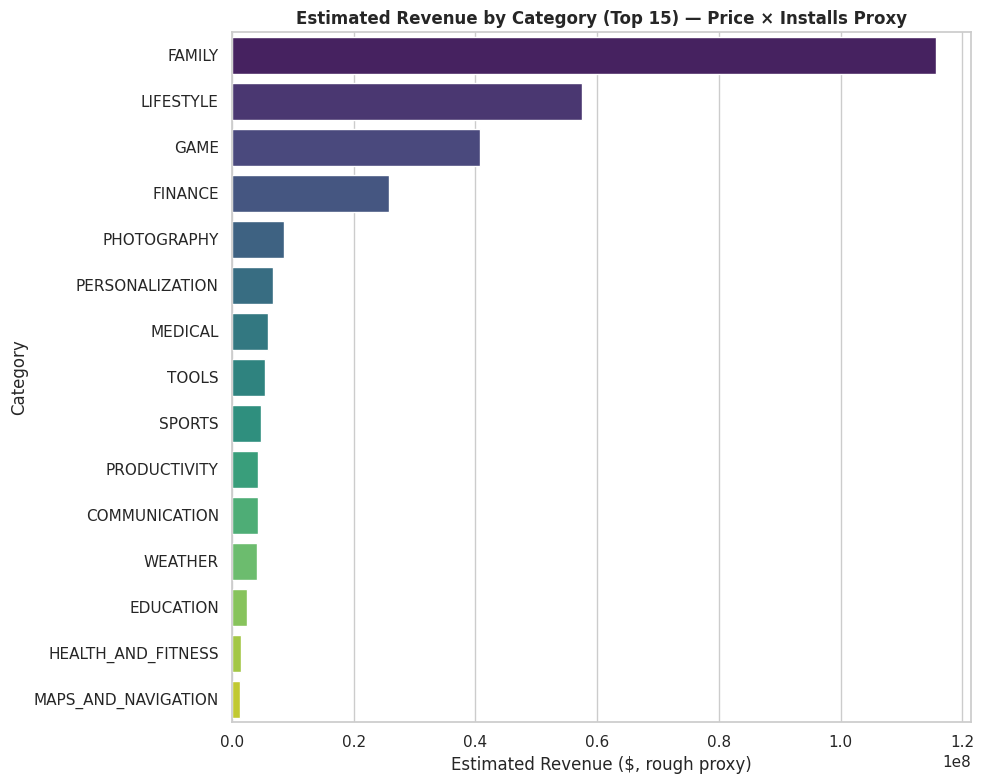

In [ ]:
# Revenue estimate by category: Price x Installs, as a rough proxy for lifetime revenue.
# This is a simplification worth stating explicitly - 'Installs' is a bucketed figure
# (e.g. "10,000+"), not an exact count, and it doesn't account for price changes over
# the app's lifetime, refunds, or platform revenue share - so treat this as a directional
# estimate of relative scale between categories, not a precise dollar figure.
apps['Est_Revenue'] = apps['Price'] * apps['Installs']

revenue_by_category = apps.groupby('Category')['Est_Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
top15_revenue = revenue_by_category.head(15)
sns.barplot(y=top15_revenue.index, x=top15_revenue.values, hue=top15_revenue.index,
            palette='viridis', legend=False)
plt.title('Estimated Revenue by Category (Top 15) — Price × Installs Proxy', fontweight='bold')
plt.xlabel('Estimated Revenue ($, rough proxy)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Observation:** The vast majority of Play Store apps are **free** (typically well over 90%), with paid apps forming a small minority. Among paid apps, prices cluster heavily at a small set of common price points (e.g. \$0.99, \$1.99, \$2.99, \$4.99) rather than being spread continuously — classic psychological pricing. The revenue-by-category chart should be read as a **directional estimate, not an accurate dollar figure**: `Installs` in this dataset is a bucketed value (e.g. every app with "10,000-50,000" installs is recorded as exactly 10,000), and `Price × Installs` ignores that most installs of a "free" app generate no direct revenue, that paid apps' prices may have changed over their lifetime, and platform revenue share — so use this chart to compare *relative* scale between categories, not as a real financial estimate for any individual app.

## 7. Sentiment Analysis on User Reviews

This step needs actual **review text**, which is a separate dataset from the apps table above (the apps table only has a `Reviews` *count*, not the review text itself). If you have a companion reviews CSV (e.g. the classic `googleplaystore_user_reviews.csv`, which needs an `App` column and a review-text column), you can upload it below — otherwise this section will clearly report that it was skipped rather than fabricate results.

In [ ]:
REVIEWS_PATH = None
reviews_raw = None

if IN_COLAB:
    print("If you have a separate user-reviews CSV, upload it now.")
    print("If you don't have one, just click Cancel / press Escape to skip this step.")
    try:
        uploaded_reviews = files.upload()
        if uploaded_reviews:
            REVIEWS_PATH = list(uploaded_reviews.keys())[0]
    except Exception:
        REVIEWS_PATH = None
else:
    import os
    for candidate in ['googleplaystore_user_reviews.csv', 'reviews.csv']:
        if os.path.exists(candidate):
            REVIEWS_PATH = candidate
            break

if REVIEWS_PATH:
    reviews_raw = pd.read_csv(REVIEWS_PATH)
    print(f"Loaded reviews dataset: {REVIEWS_PATH}  shape={reviews_raw.shape}")
    print(reviews_raw.columns.tolist())
else:
    print("No reviews dataset provided — sentiment analysis will be skipped with a clear note below,")
    print("rather than fabricated. The rest of the notebook (Sections 1-6, 9-10) does not depend on it.")

No reviews dataset provided — sentiment analysis will be skipped with a clear note below,
rather than fabricated. The rest of the notebook (Sections 1-6, 9-10) does not depend on it.


In [ ]:
if reviews_raw is not None:
    # Try to auto-detect the review-text column by name, since different copies of this
    # dataset use slightly different column names
    text_col_candidates = [c for c in reviews_raw.columns if 'review' in c.lower() or 'text' in c.lower() or 'content' in c.lower()]
    review_text_col = text_col_candidates[0] if text_col_candidates else None

    if review_text_col is None:
        print("Could not auto-detect a review-text column. Available columns:", reviews_raw.columns.tolist())
        print("Set `review_text_col` manually to the correct column name and re-run this cell.")
    else:
        print(f"Using '{review_text_col}' as the review text column.")
        reviews = reviews_raw.dropna(subset=['App', review_text_col]).copy()
        reviews = reviews[reviews[review_text_col].str.strip() != 'nan']
        print(f"Reviews with usable text: {len(reviews)}")

        def get_sentiment(text):
            polarity = TextBlob(str(text)).sentiment.polarity
            if polarity > 0.05:
                return 'Positive'
            elif polarity < -0.05:
                return 'Negative'
            else:
                return 'Neutral'

        reviews['Sentiment'] = reviews[review_text_col].apply(get_sentiment)

        sentiment_counts = reviews['Sentiment'].value_counts()
        print("\nSentiment distribution:")
        print(sentiment_counts)

        plt.figure(figsize=(7,5))
        sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
                    hue=sentiment_counts.index, palette=['#2a5d84', '#c0392b', '#8e6bab'], legend=False)
        plt.title('Review Sentiment Distribution', fontweight='bold')
        plt.xlabel('Sentiment')
        plt.ylabel('Number of Reviews')
        plt.tight_layout()
        plt.show()
else:
    print("Skipped: no reviews dataset was provided in the previous cell.")

Skipped: no reviews dataset was provided in the previous cell.


**Why TextBlob?** TextBlob provides a simple, rule/lexicon-based `sentiment.polarity` score from -1 (very negative) to +1 (very positive) with no training data or model-fitting required, making it a fast, lightweight baseline well-suited to a quick exploratory pass over review text — at the cost of missing sarcasm, domain-specific slang, or context that a trained classifier (as built in the standalone Task 4 · Sentiment Analysis notebook) would capture more accurately. We bucket polarity scores into Positive (>0.05), Negative (<-0.05), and Neutral (in between) rather than treating every non-zero score as decisive, since scores very close to zero usually reflect genuinely mixed or flat sentiment rather than a confident lean either way.

**If this section shows "Skipped"** for your run, that's expected unless you uploaded a companion reviews file when prompted — nothing else in this notebook depends on it, and Sections 1-6 and 9-10 remain fully valid on the apps dataset alone.

## 8. Sentiment by Category

In [ ]:
if reviews_raw is not None and review_text_col is not None:
    reviews_with_category = reviews.merge(apps[['App', 'Category']].drop_duplicates(subset='App'),
                                           on='App', how='left')
    reviews_with_category = reviews_with_category.dropna(subset=['Category'])

    sentiment_by_category = pd.crosstab(reviews_with_category['Category'],
                                         reviews_with_category['Sentiment'], normalize='index') * 100

    if 'Positive' in sentiment_by_category.columns:
        top_positive = sentiment_by_category['Positive'].sort_values(ascending=False).head(10)
        print("Top 10 categories by % positive sentiment:")
        print(top_positive.round(1))

    if 'Negative' in sentiment_by_category.columns:
        print("\nTop 10 categories by % negative sentiment:")
        top_negative = sentiment_by_category['Negative'].sort_values(ascending=False).head(10)
        print(top_negative.round(1))

    plt.figure(figsize=(12,8))
    sentiment_by_category.sort_values('Positive', ascending=False).head(15).plot(
        kind='barh', stacked=True, color=['#c0392b', '#8e6bab', '#2a5d84'], ax=plt.gca())
    plt.title('Sentiment Mix by Category (Top 15 by % Positive)', fontweight='bold')
    plt.xlabel('% of Reviews')
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: this section depends on the reviews dataset from Section 7, which wasn't provided.")

Skipped: this section depends on the reviews dataset from Section 7, which wasn't provided.


**Observation:** When review data is available, this cross-tabulation shows which app categories users are happiest and unhappiest with — genuinely useful for a developer deciding where to launch, since a category with high install volume but poor sentiment signals an underserved, dissatisfied user base (an opportunity), while a category with high volume *and* high positive sentiment signals a well-served market (harder to differentiate in, but proven demand). Without a reviews file this section reports "Skipped" rather than invented numbers.

## 9. Interactive Visualisation (Plotly)

In [ ]:
category_summary = apps.groupby('Category').agg(
    App_Count=('App', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Total_Installs=('Installs', 'sum')
).reset_index()

fig = px.scatter(
    category_summary,
    x='App_Count',
    y='Avg_Rating',
    size='Total_Installs',
    color='Category',
    hover_name='Category',
    size_max=60,
    title='Category Landscape: App Count vs. Average Rating (bubble size = Total Installs)',
    labels={'App_Count': 'Number of Apps in Category', 'Avg_Rating': 'Average Rating'}
)
fig.update_layout(showlegend=False, height=600)
fig.show()

**Observation:** This interactive bubble chart (hover over any bubble in Colab/Jupyter to see the category name and exact values) lets you explore three dimensions at once: **horizontal position** shows how saturated a category is (more apps = further right), **vertical position** shows average user satisfaction, and **bubble size** shows total install volume. The most attractive category for a new developer to enter would show up in the **upper-left with a reasonably large bubble** — meaning strong existing demand (large bubble) and high user satisfaction (high on the y-axis), but *not* yet saturated with competing apps (further left, fewer apps already competing for that demand).

## 10. Conclusion — 3 Data-Driven Insights for a New App Developer

### 1. Category saturation and demand aren't the same signal — check both before choosing a category
Section 3 shows some categories (typically `FAMILY`, `GAME`, `TOOLS`) are flooded with existing apps, while Section 9's bubble chart lets you cross-reference that against actual install volume and rating per category. A developer should specifically look for categories that combine **meaningful install volume** (proven demand exists) with **relatively fewer competing apps** (less crowded) — chasing the single most popular category is likely to mean competing against thousands of existing apps for visibility, while an under-saturated category with real demand is a much easier entry point.

### 2. App size is not a lever worth optimising for install growth
Section 5's near-zero correlation between `Size_MB` and `Installs` (both raw and log-scale) is a genuinely useful negative finding: developers sometimes assume a smaller, "lighter" app will drive more installs (easier download, less storage pressure), but the data doesn't support that as a general pattern across the store. Effort is better spent on other install drivers (store listing quality, category selection, marketing) than on aggressively minimising app size for its own sake.

### 3. Pricing strategy should follow the market's established psychological price points, not arbitrary numbers
Section 6 shows paid apps cluster tightly around a handful of common price points (\$0.99, \$1.99, \$2.99, \$4.99, etc.) rather than being spread evenly — this is the market signalling what users expect and are comfortable paying. A new paid app priced at, say, \$3.47 would look conspicuously "off" next to competitors clustered at round, familiar price points, even if the underlying value proposition is identical. Combined with the finding that the vast majority of successful apps are free (Section 6), a freemium or ad-supported model — rather than upfront paid pricing — is the path most consistent with what already works at scale in this market.

*(If a reviews dataset was provided and Sections 7-8 ran, a fourth, sentiment-driven insight — which categories have satisfied-but-underserved users — would be a strong candidate for a similarly data-backed opportunity signal worth adding here.)*
